# 7. Evaluacija modela u mašinskom učenju

## Generalizacija

Cilj mašinskog učenja je da se model **dobro generalizuje** na nove, neviđene podatke:
visoka tačnost generalizacije, niska greška generalizacije.

$$\text{Tačnost} = 1 - \text{greška}$$

## Overfitting i underfitting

| | trening greška | test greška |
|---|---|---|
| **underfitting** (podobučavanje) | **velika** | velika |
| **overfitting** (preprilagođavanje) | **mala** | **velika** |

| uzroci underfittinga | uzroci overfittinga |
|---|---|
| model previše jednostavan | veliki kapacitet modela |
| mali kapacitet | malo podataka |
| nedovoljno treniranja | predugo treniranje |
| važne osobine nisu uključene | previše parametara |

### Kapacitet modela

Kapacitet govori **koliko je model fleksibilan**. Raste kada model ima više parametara,
dublju strukturu, nelinearne funkcije, ili manje ograničenja (regularizacije).

Primer: stablo dubine 1 (*decision stump*) ima mali kapacitet; duboko stablo veliki.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score, KFold, StratifiedKFold,
                                     LeaveOneOut, learning_curve, validation_curve, GridSearchCV)
from sklearn.datasets import make_classification, load_breast_cancer, load_digits
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score, balanced_accuracy_score,
                             roc_curve, roc_auc_score, classification_report,
                             precision_recall_curve, average_precision_score)

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42
rng = np.random.RandomState(RS)
print("Spremno.")

Spremno.


## Bias–Variance razlaganje

$$\text{Greška} = \text{Bias}^2 + \text{Varijansa} + \text{Šum}$$

| komponenta | definicija | uzrok |
|---|---|---|
| **Bias** | $\mathbb{E}[\hat\theta] - \theta$ — sistematska greška | model previše jednostavan → underfitting |
| **Varijansa** | $\mathbb{E}\big[(\hat\theta - \mathbb{E}[\hat\theta])^2\big]$ — osetljivost na podatke | model previše složen → overfitting |
| **Šum** | neizbežna slučajnost | ne može se ukloniti nijednim modelom |

### Intuicija

> **Bias** meri koliko smo daleko od cilja → **tačnost**.
> **Varijansa** meri koliko smo rasuti oko proseka → **stabilnost**.

| bias | varijansa | opis |
|---|---|---|
| nizak | niska | idealno: tačan i stabilan |
| nizak | visoka | u proseku pogađa, ali su predikcije rasute (duboka stabla) |
| visok | niska | konzistentno pogrešan (linearni model za nelinearan problem) |
| visok | visoka | najgore: pogrešan i nestabilan |

### Zašto srednji član nestaje u izvođenju

$$\mathbb{E}\big[2(y - \mathbb{E}[\hat y])(\mathbb{E}[\hat y] - \hat y)\big]
= 2(y - \mathbb{E}[\hat y]) \cdot \underbrace{\mathbb{E}\big[\mathbb{E}[\hat y] - \hat y\big]}_{= \, \mathbb{E}[\hat y] - \mathbb{E}[\hat y] \, = \, 0} = 0$$

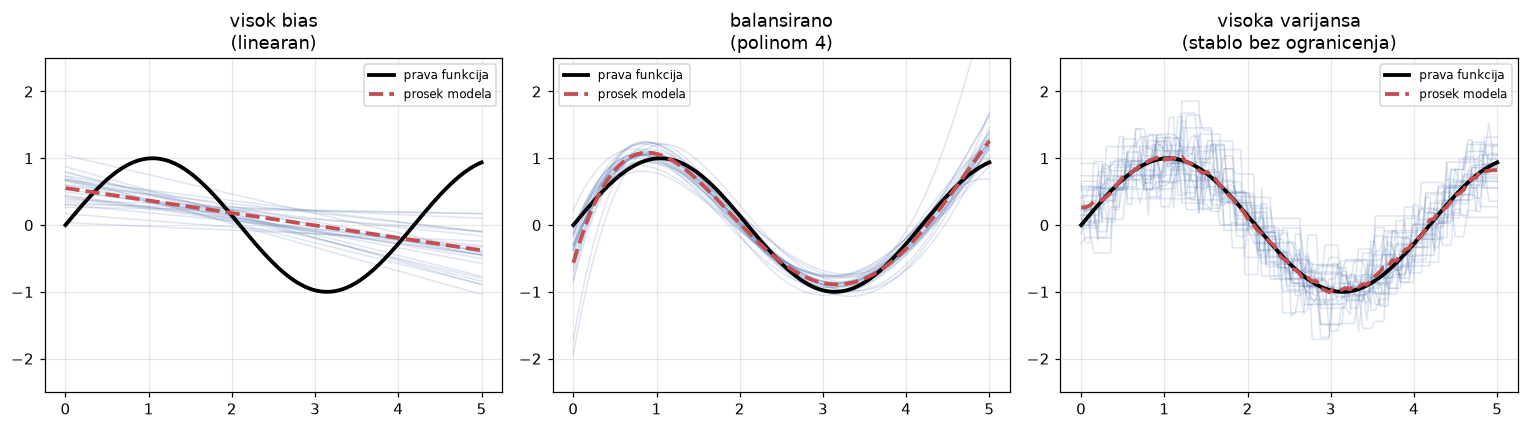

,model,bias^2,varijansa,zbir
0,visok bias (linearan),0.4131,0.0419,0.4550
1,balansirano (polinom 4),0.0166,0.0378,0.0545
2,visoka varijansa (stablo bez ogranicenja),0.0028,0.1004,0.1032


In [2]:
# simulacija: treniramo isti model na 60 razlicitih trening skupova
def prava_f(x): return np.sin(1.5 * x)

x_test = np.linspace(0, 5, 100).reshape(-1, 1)
y_pravo = prava_f(x_test).ravel()

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
rezultat = []
for a, (ime, napravi) in zip(ax, [
        ("visok bias\n(linearan)", lambda: LinearRegression()),
        ("balansirano\n(polinom 4)", lambda: make_pipeline(PolynomialFeatures(4), LinearRegression())),
        ("visoka varijansa\n(stablo bez ogranicenja)", lambda: DecisionTreeRegressor(random_state=None))]):
    predikcije = []
    for i in range(60):
        r = np.random.RandomState(i)
        xt = r.uniform(0, 5, 30).reshape(-1, 1)
        yt = prava_f(xt).ravel() + r.normal(0, 0.3, 30)
        p = napravi().fit(xt, yt).predict(x_test)
        predikcije.append(p)
        if i < 25:
            a.plot(x_test, p, color="#4C72B0", alpha=0.18, lw=1)
    P = np.array(predikcije)
    bias2 = np.mean((P.mean(0) - y_pravo) ** 2)
    var = np.mean(P.var(0))
    rezultat.append({"model": ime.replace("\n", " "), "bias^2": round(bias2, 4),
                     "varijansa": round(var, 4), "zbir": round(bias2 + var, 4)})
    a.plot(x_test, y_pravo, color="k", lw=2.5, label="prava funkcija")
    a.plot(x_test, P.mean(0), color="#C44E52", lw=2.5, ls="--", label="prosek modela")
    a.set_title(ime); a.legend(fontsize=8); a.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()
pd.DataFrame(rezultat)

## Hiperparametri

Hiperparametri se **ne uče iz podataka**, već se postavljaju **pre** treniranja. Kontrolišu
složenost, kapacitet i bias–variance kompromis.

| model | hiperparametri |
|---|---|
| **k-NN** | broj suseda $k$, mera rastojanja |
| **stablo** | `max_depth`, `min_samples_leaf`, `min_samples_split` |
| **logistička regresija** | jačina L2-regularizacije $\lambda$ (u sklearn: $C = 1/\lambda$) |

Za logističku regresiju sa L2-regularizacijom:

$$\mathcal{L}(w) = -\sum_{i=1}^{n}\big[y_i\log\hat y_i + (1-y_i)\log(1-\hat y_i)\big] + \lambda\lVert w\rVert_2^2$$

| $\lambda$ | regularizacija | bias | varijansa |
|---|---|---|---|
| veliko | jača | veći | manja |
| malo | slabija | manji | veća |

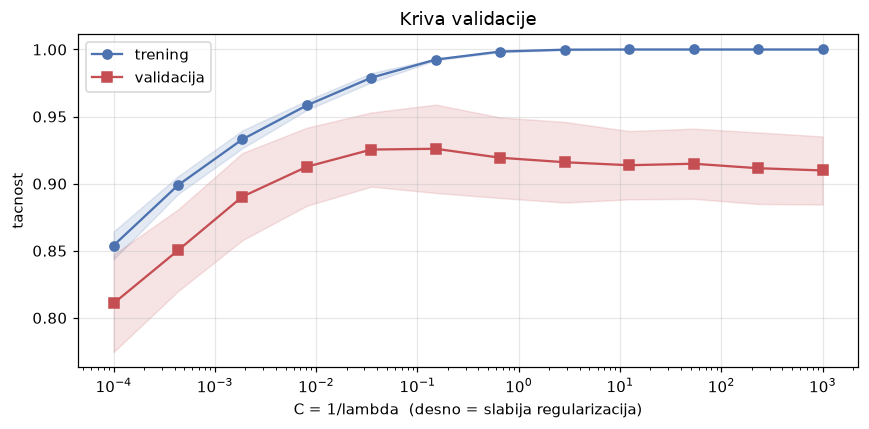

Najbolje C = 0.1520, tacnost 0.9260


In [3]:
Xd, yd = load_digits(return_X_y=True)
opseg = np.logspace(-4, 3, 12)
tr, te = validation_curve(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    Xd, yd, param_name="logisticregression__C", param_range=opseg, cv=5, n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(opseg, tr.mean(1), "o-", label="trening", color="#4C72B0")
ax.fill_between(opseg, tr.mean(1)-tr.std(1), tr.mean(1)+tr.std(1), alpha=0.15, color="#4C72B0")
ax.semilogx(opseg, te.mean(1), "s-", label="validacija", color="#C44E52")
ax.fill_between(opseg, te.mean(1)-te.std(1), te.mean(1)+te.std(1), alpha=0.15, color="#C44E52")
ax.set_xlabel("C = 1/lambda  (desno = slabija regularizacija)"); ax.set_ylabel("tacnost")
ax.set_title("Kriva validacije"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Najbolje C = {opseg[int(np.argmax(te.mean(1)))]:.4f}, tacnost {te.mean(1).max():.4f}")

## Podela podataka i izbor hiperparametara

Ispravan postupak, korak po korak:

1. Model se trenira na **trening** skupu, za različite vrednosti hiperparametara
2. Evaluacija na **validacionom** skupu → biraju se najbolji hiperparametri
3. Izbor se **zaključava**, model se ponovo trenira na (train + validation)
4. Performanse se mere **jednom**, isključivo na **test** skupu

> **Test skup se ne koristi tokom izbora hiperparametara.** Ako se koristi, prestaje da bude
> neviđen i procena postaje optimistična.

## Unakrsna validacija

$$\text{Performance} = \frac{1}{k}\sum_{i=1}^{k}\text{Performance}_i$$

Preporučeni izbori u praksi: **$k = 5$** ili **$k = 10$**.

| varijanta | opis |
|---|---|
| **Holdout** | jedna podela; brz, ali nestabilna procena |
| **2-fold** | jednostavan, ali visoka varijansa procene |
| **Ponavljani holdout** | više nasumičnih podela, prosek |
| **LOOCV** ($k = n$) | maksimalno koristi podatke; računski vrlo skup |

Kako $k$ raste: **bias opada**, ali **varijansa i računska cena rastu**.

In [4]:
Xs, ys = make_classification(n_samples=220, n_features=12, n_informative=6,
                             random_state=RS)
model = DecisionTreeClassifier(max_depth=4, random_state=RS)

import time
print(f"{'metoda':<28} {'prosek':>8} {'st.dev':>8} {'vreme':>8}")
print("-" * 56)
for ime, cv in [("holdout (2-fold)", KFold(2, shuffle=True, random_state=RS)),
                ("5-fold", StratifiedKFold(5, shuffle=True, random_state=RS)),
                ("10-fold", StratifiedKFold(10, shuffle=True, random_state=RS)),
                ("LOOCV (k = n)", LeaveOneOut())]:
    t0 = time.time()
    s = cross_val_score(model, Xs, ys, cv=cv, n_jobs=-1)
    print(f"{ime:<28} {s.mean():>8.4f} {s.std():>8.4f} {time.time()-t0:>7.2f}s")

metoda                         prosek   st.dev    vreme
--------------------------------------------------------
holdout (2-fold)               0.7591   0.0591    0.04s
5-fold                         0.7455   0.0617    0.04s
10-fold                        0.7182   0.0445    0.05s


LOOCV (k = n)                  0.7182   0.4499    0.13s


## Krive učenja — da li treba više podataka

Kriva učenja pokazuje da li je model ograničen **količinom podataka** ili **sopstvenim
kapacitetom**:

- ako validaciona kriva **još raste** → više podataka bi pomoglo
- ako je **ravna**, a razmak od trening krive velik → **overfitting**, treba jednostavniji model ili regularizacija
- ako su **obe niske i blizu** → **underfitting**, treba složeniji model

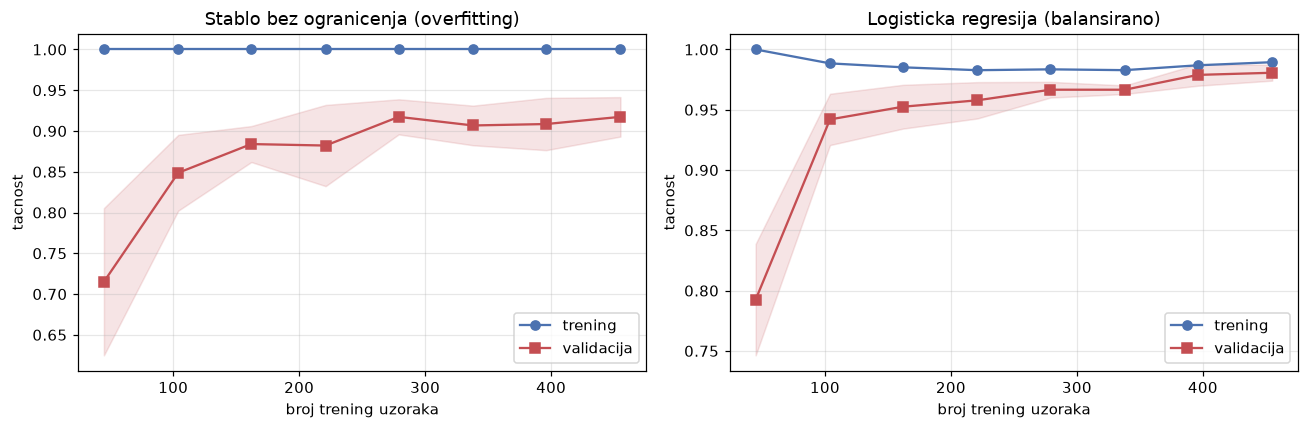

In [5]:
Xb, yb = load_breast_cancer(return_X_y=True)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (ime, m) in zip(ax, [("Stablo bez ogranicenja (overfitting)", DecisionTreeClassifier(random_state=RS)),
                            ("Logisticka regresija (balansirano)",
                             make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)))]):
    n, tr, te = learning_curve(m, Xb, yb, cv=5, n_jobs=-1,
                               train_sizes=np.linspace(0.1, 1.0, 8))
    a.plot(n, tr.mean(1), "o-", label="trening", color="#4C72B0")
    a.plot(n, te.mean(1), "s-", label="validacija", color="#C44E52")
    a.fill_between(n, te.mean(1)-te.std(1), te.mean(1)+te.std(1), alpha=0.15, color="#C44E52")
    a.set_xlabel("broj trening uzoraka"); a.set_ylabel("tacnost")
    a.set_title(ime); a.legend()
plt.tight_layout(); plt.show()

## Mere performansi — matrica konfuzije

|  | predviđeno 0 | predviđeno 1 |
|---|---|---|
| **stvarno 0** | TN | FP |
| **stvarno 1** | FN | TP |

$$ERR = \frac{FP+FN}{TP+TN+FP+FN} \qquad ACC = \frac{TP+TN}{TP+TN+FP+FN} = 1 - ERR$$

$$\text{Precision} = \frac{TP}{TP+FP} \qquad
\text{Recall} = \frac{TP}{TP+FN} \qquad
F_1 = 2\cdot\frac{P \cdot R}{P + R}$$

**Preciznost** odgovara na pitanje: *od svih koje sam označio kao pozitivne, koliko je zaista pozitivno?*
**Odziv** odgovara: *od svih stvarno pozitivnih, koliko sam ih pronašao?*
**F1** je harmonijska sredina te dve mere.

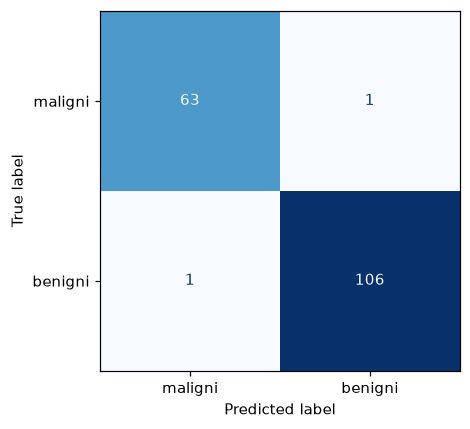

TN=63  FP=1  FN=1  TP=106

ERR        = (FP+FN)/n  = 0.0117
ACC        = (TP+TN)/n  = 0.9883   = 1 - ERR
Preciznost = TP/(TP+FP) = 0.9907
Odziv      = TP/(TP+FN) = 0.9907
F1                       = 0.9907


In [6]:
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.3, random_state=RS, stratify=yb)
m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xtr, ytr)
pred = m.predict(Xte)
cm = confusion_matrix(yte, pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["maligni", "benigni"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.grid(False); plt.tight_layout(); plt.show()

print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}\n")
print(f"ERR        = (FP+FN)/n  = {(fp+fn)/cm.sum():.4f}")
print(f"ACC        = (TP+TN)/n  = {(tp+tn)/cm.sum():.4f}   = 1 - ERR")
print(f"Preciznost = TP/(TP+FP) = {tp/(tp+fp):.4f}")
print(f"Odziv      = TP/(TP+FN) = {tp/(tp+fn):.4f}")
print(f"F1                       = {f1_score(yte, pred):.4f}")

## Balansirani i nebalansirani skupovi

**Balansiran skup** — sve klase imaju sličan broj uzoraka; tačnost je pouzdana metrika.

**Nebalansiran skup** — jedna klasa je znatno manje zastupljena. Tada model može imati
**visoku tačnost, a da uopšte ne detektuje manjinsku klasu** — koja je često najvažnija
(medicina, prevare).

> **Zato tačnost „vara" kod nebalansiranih podataka.**

Metrike koje treba koristiti: **Precision / Recall**, **F1**, **ROC-AUC**,
**Balanced Accuracy / APC**.

### Balanced / APC accuracy

Svaka klasa je jednako važna bez obzira na veličinu — izračuna se tačnost po klasi, pa
aritmetička sredina:

$$APC = \frac{ACC_{\text{klasa 0}} + ACC_{\text{klasa 1}} + ACC_{\text{klasa 2}}}{3}$$

In [7]:
Xi, yi = make_classification(n_samples=3000, n_features=15, n_informative=6,
                             weights=[0.96, 0.04], random_state=RS)
Xtr2, Xte2, ytr2, yte2 = train_test_split(Xi, yi, test_size=0.3, random_state=RS, stratify=yi)
print(f"Raspodela klasa: {np.bincount(yi).tolist()}  ->  manjinska klasa {yi.mean():.1%}\n")

from sklearn.dummy import DummyClassifier
redovi = []
for ime, mod in [("Dummy (uvek vecinska)", DummyClassifier(strategy="most_frequent")),
                 ("LogReg (bez tezina)", make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))),
                 ("LogReg (class_weight)", make_pipeline(StandardScaler(),
                                            LogisticRegression(max_iter=3000, class_weight="balanced")))]:
    mod.fit(Xtr2, ytr2); p = mod.predict(Xte2)
    redovi.append({"model": ime,
                   "tacnost": round(accuracy_score(yte2, p), 4),
                   "balanced_acc": round(balanced_accuracy_score(yte2, p), 4),
                   "preciznost": round(precision_score(yte2, p, zero_division=0), 4),
                   "odziv": round(recall_score(yte2, p), 4),
                   "F1": round(f1_score(yte2, p), 4)})
display(pd.DataFrame(redovi))
print("-> Dummy ima tacnost ~96%, a odziv 0. Tacnost potpuno zavarava.")
print("   Balanced accuracy i F1 to odmah otkrivaju.")

Raspodela klasa: [2868, 132]  ->  manjinska klasa 4.4%



,model,tacnost,balanced_acc,preciznost,odziv,F1
0,Dummy (uvek vecinska),0.9556,0.5000,0.0000,0.000,0.0000
1,LogReg (bez tezina),0.9633,0.6233,0.7692,0.250,0.3774
2,LogReg (class_weight),0.8222,0.8474,0.1842,0.875,0.3043


-> Dummy ima tacnost ~96%, a odziv 0. Tacnost potpuno zavarava.
   Balanced accuracy i F1 to odmah otkrivaju.


## ROC kriva i AUC

ROC prikazuje odnos:

$$TPR = \frac{TP}{TP+FN} \qquad FPR = \frac{FP}{FP+TN}$$

- kriva bliža **gornjem levom uglu** → bolji model
- **dijagonala** → slučajno pogađanje

**AUC** (površina ispod ROC krive) sažima sve u jedan broj:

| AUC | tumačenje |
|---|---|
| 1.0 | savršen model |
| 0.8 | dobar model |
| 0.5 | slučajno pogađanje |

AUC je **verovatnoća da će model dodeliti veći skor pozitivnom nego negativnom primeru**.

> **Napomena:** kod jako nebalansiranih skupova ROC-AUC deluje optimistično, jer u obračun
> ulazi i ogroman broj lako prepoznatljivih negativnih primera. Tada je **PR kriva**
> (preciznost–odziv) informativnija.

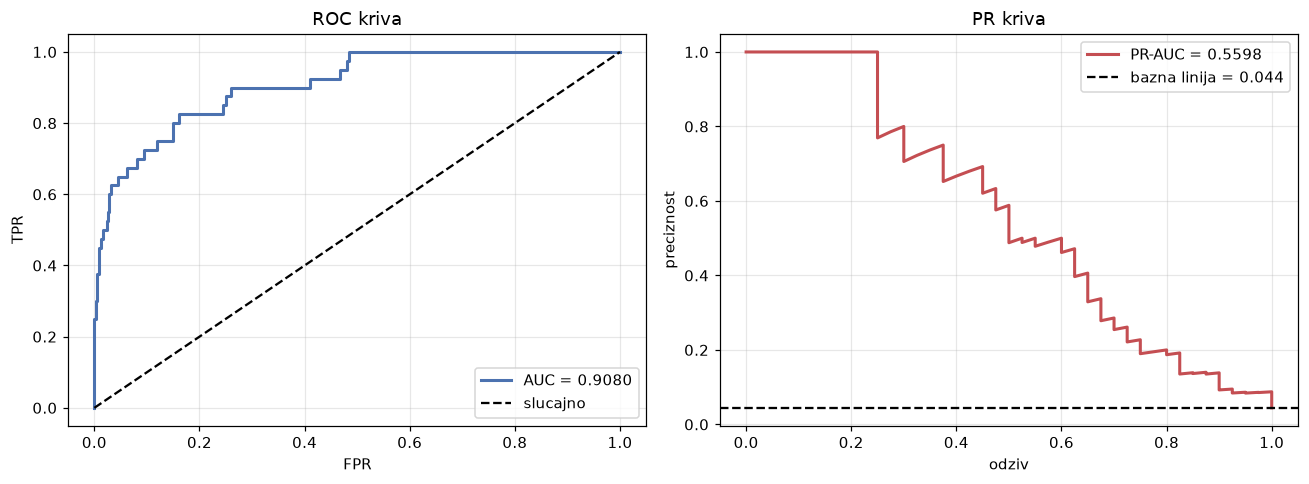

ROC-AUC = 0.9080   <- deluje odlicno
PR-AUC  = 0.5598   <- realnija slika pri 4.4% pozitivnih


In [8]:
mod = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xtr2, ytr2)
skor = mod.predict_proba(Xte2)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(yte2, skor)
ax[0].plot(fpr, tpr, lw=2, color="#4C72B0", label=f"AUC = {roc_auc_score(yte2, skor):.4f}")
ax[0].plot([0,1],[0,1],"k--", label="slucajno")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("ROC kriva"); ax[0].legend()

pr, rc, _ = precision_recall_curve(yte2, skor)
ax[1].plot(rc, pr, lw=2, color="#C44E52", label=f"PR-AUC = {average_precision_score(yte2, skor):.4f}")
ax[1].axhline(yte2.mean(), color="k", ls="--", label=f"bazna linija = {yte2.mean():.3f}")
ax[1].set_xlabel("odziv"); ax[1].set_ylabel("preciznost"); ax[1].set_title("PR kriva"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"ROC-AUC = {roc_auc_score(yte2, skor):.4f}   <- deluje odlicno")
print(f"PR-AUC  = {average_precision_score(yte2, skor):.4f}   <- realnija slika pri {yte2.mean():.1%} pozitivnih")

## Makro i mikro proseci

Kod **višeklasnih** problema metrike se mogu računati na dva načina:

| | kako se računa | ko dominira | kada koristiti |
|---|---|---|---|
| **Micro** | sabiraju se svi TP, FP, FN preko klasa | **dominantne klase** | klase približno balansirane |
| **Macro** | metrika po klasi, pa aritmetički prosek | **sve klase jednako** | podaci nebalansirani |

> **Micro:** „Koliko sam dobar u proseku **po uzorku**?"
> **Macro:** „Koliko sam dobar u proseku **po klasi**?"

Kod nebalansiranih skupova **macro** daje realniju sliku, jer ne dozvoljava da velika klasa
sakrije loš rezultat na maloj.

In [9]:
Xm, ym = make_classification(n_samples=1500, n_features=12, n_informative=6,
                             n_classes=3, n_clusters_per_class=1,
                             weights=[0.75, 0.20, 0.05], random_state=RS)
Xtr3, Xte3, ytr3, yte3 = train_test_split(Xm, ym, test_size=0.3, random_state=RS, stratify=ym)
mm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xtr3, ytr3)
p3 = mm.predict(Xte3)

print(f"Raspodela klasa: {np.bincount(ym).tolist()}\n")
print(classification_report(yte3, p3, digits=4))
print(f"F1 micro = {f1_score(yte3, p3, average='micro'):.4f}")
print(f"F1 macro = {f1_score(yte3, p3, average='macro'):.4f}   <- nizi, jer kaznjava lose")
print("                                       rezultate na maloj klasi 2")

Raspodela klasa: [1122, 300, 78]



              precision    recall  f1-score   support

           0     0.9517    0.9941    0.9724       337
           1     0.9875    0.8778    0.9294        90
           2     0.8889    0.6957    0.7805        23

    accuracy                         0.9556       450
   macro avg     0.9427    0.8558    0.8941       450
weighted avg     0.9557    0.9556    0.9540       450

F1 micro = 0.9556
F1 macro = 0.8941   <- nizi, jer kaznjava lose
                                       rezultate na maloj klasi 2


## Kontrolna lista za evaluaciju

- [ ] podaci podeljeni na **train / validation / test**, test korišćen **samo jednom**
- [ ] preprocesiranje (skaliranje, imputacija) naučeno **samo na trening skupu**
- [ ] kod grupisanih podataka koristi se `GroupKFold`, ne obična `KFold`
- [ ] metrika izabrana prema **raspodeli klasa** — ne tačnost kod nebalansiranih
- [ ] uvek prijavljena **bazna linija** (`DummyClassifier`), da se vidi šta je „loše"
- [ ] rezultat prijavljen sa **standardnom devijacijom** iz kros-validacije
- [ ] pogledana **kriva učenja** — da se zna da li treba više podataka ili drugi model